In [1]:
import pandas as pd
import numpy as np

In [3]:
DATA_PATH = "../data/raw/customer_churn.csv"
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,customer_id,age,tenure_months,monthly_charges,contract_type,internet_service,tech_support,online_security,payment_method,customer_service_calls,churn
0,1,56,1,121.34,One year,Fiber optic,No,Yes,Electronic check,1,1
1,2,69,10,52.84,One year,Fiber optic,No,No,Bank transfer,6,1
2,3,46,36,127.85,One year,No,No,No,Credit card,1,0
3,4,32,46,111.51,Two year,Fiber optic,No,No,Electronic check,0,0
4,5,60,32,142.94,Month-to-month,Fiber optic,No,No,Credit card,2,1


In [5]:
df.shape

(5000, 11)

In [6]:
df.columns

Index(['customer_id', 'age', 'tenure_months', 'monthly_charges',
       'contract_type', 'internet_service', 'tech_support', 'online_security',
       'payment_method', 'customer_service_calls', 'churn'],
      dtype='object')

In [7]:
df.dtypes

customer_id                 int64
age                         int64
tenure_months               int64
monthly_charges           float64
contract_type              object
internet_service           object
tech_support               object
online_security            object
payment_method             object
customer_service_calls      int64
churn                       int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   int64  
 1   age                     5000 non-null   int64  
 2   tenure_months           5000 non-null   int64  
 3   monthly_charges         5000 non-null   float64
 4   contract_type           5000 non-null   object 
 5   internet_service        5000 non-null   object 
 6   tech_support            5000 non-null   object 
 7   online_security         5000 non-null   object 
 8   payment_method          5000 non-null   object 
 9   customer_service_calls  5000 non-null   int64  
 10  churn                   5000 non-null   int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 429.8+ KB


In [9]:
df.isnull().sum()

customer_id               0
age                       0
tenure_months             0
monthly_charges           0
contract_type             0
internet_service          0
tech_support              0
online_security           0
payment_method            0
customer_service_calls    0
churn                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [12]:
df["contract_type"].value_counts()

contract_type
Month-to-month    2747
One year          1239
Two year          1014
Name: count, dtype: int64

In [13]:
df["internet_service"].value_counts()

internet_service
Fiber optic    2546
DSL            1416
No             1038
Name: count, dtype: int64

In [14]:
df["payment_method"].value_counts()

payment_method
Credit card         1788
Electronic check    1730
Bank transfer       1482
Name: count, dtype: int64

In [15]:
df["churn"].value_counts()

churn
1    3621
0    1379
Name: count, dtype: int64

In [16]:
df["churn"].value_counts(normalize=True) * 100

churn
1    72.42
0    27.58
Name: proportion, dtype: float64

In [17]:
df.select_dtypes(include=np.number).corr()

,customer_id,age,tenure_months,monthly_charges,customer_service_calls,churn
customer_id,1.000000,-0.010360,-0.002188,0.019659,0.000338,-0.018063
age,-0.010360,1.000000,-0.013998,0.035254,0.004688,-0.057113
tenure_months,-0.002188,-0.013998,1.000000,-0.000248,-0.025275,-0.200761
monthly_charges,0.019659,0.035254,-0.000248,1.000000,-0.003803,-0.005298
customer_service_calls,0.000338,0.004688,-0.025275,-0.003803,1.000000,0.094938
churn,-0.018063,-0.057113,-0.200761,-0.005298,0.094938,1.000000


In [19]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.7 MB/s  0:00:02 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 3.3 MB/s  0:00:01 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m6/8 [matplotlib]


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

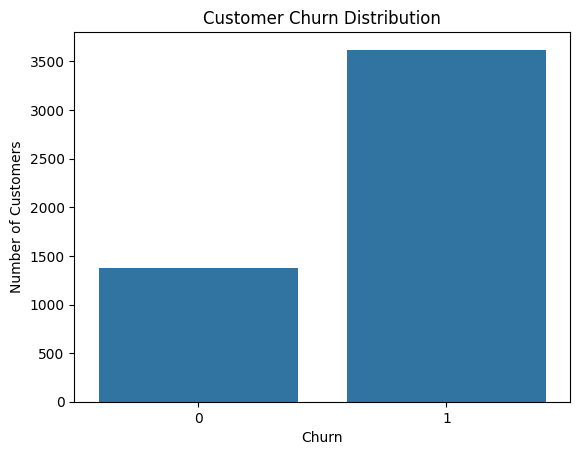

In [21]:
sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

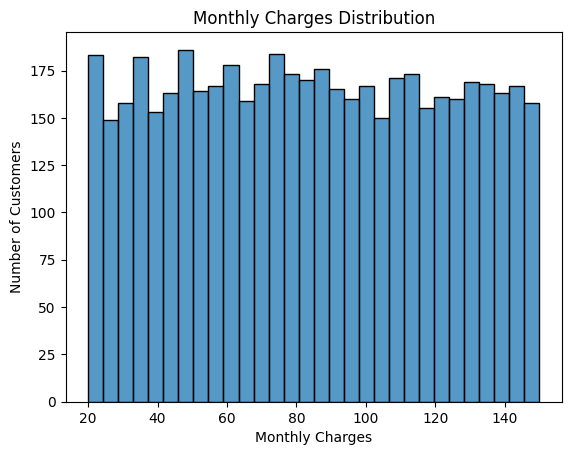

In [22]:
sns.histplot(
    data=df,
    x="monthly_charges",
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

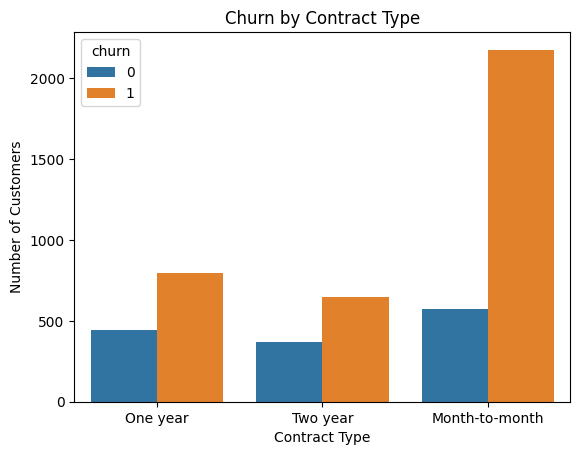

In [23]:
sns.countplot(
    data=df,
    x="contract_type",
    hue="churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
assert df.shape[0] == 5000

In [25]:
assert "churn" in df.columns

In [26]:
assert df["churn"].isin([0, 1]).all()

In [27]:
assert df["customer_id"].is_unique

In [28]:
assert df.isnull().sum().sum() == 0

In [29]:
X = df.drop(columns=["churn"])
y = df["churn"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 10)
(1000, 10)
(4000,)
(1000,)


In [33]:
train_data = X_train.copy()
train_data["churn"] = y_train

test_data = X_test.copy()
test_data["churn"] = y_test

In [34]:
train_data.to_csv(
    "../data/processed/train.csv",
    index=False
)

test_data.to_csv(
    "../data/processed/test.csv",
    index=False
)